## Dataset overview

In this section we inspect the structure of the dataset:

- number of rows and columns  
- column names  
- missing values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Sales distribution

We analyze how sales values are distributed across all transactions.

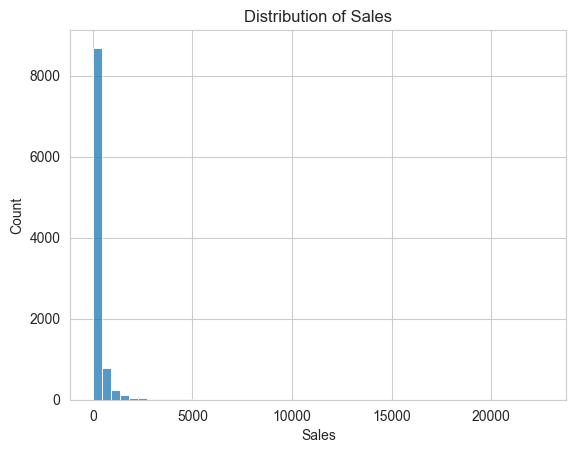

In [6]:
sns.histplot(df["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.show()

In [7]:
df["Sales"].max()

np.float64(22638.48)

## Sales by category

We analyze total sales by product category to understand which product groups generate the most revenue.

In [8]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

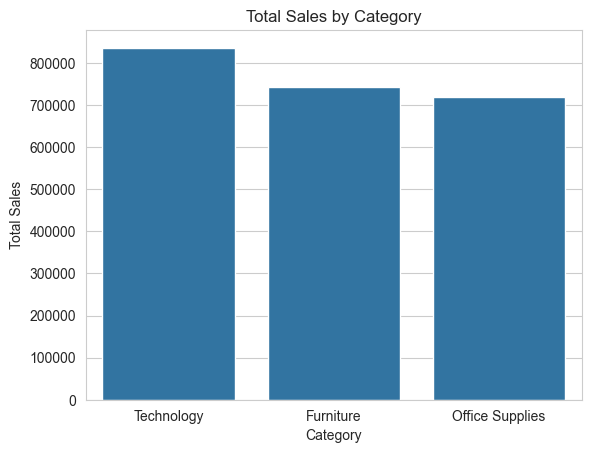

In [9]:
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## Profit by category

We analyze total profit by product category to understand which categories are most profitable.

In [10]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

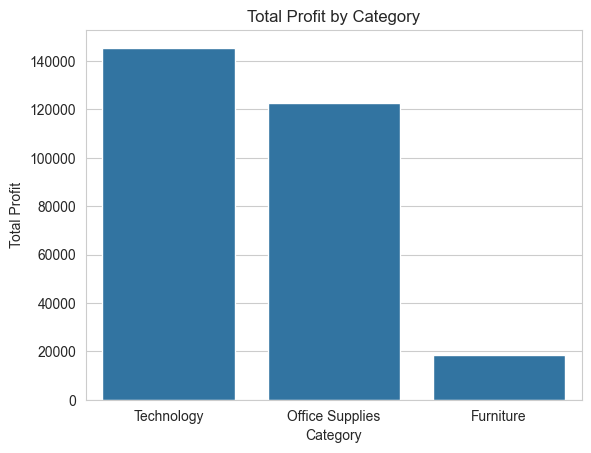

In [11]:
sns.barplot(x=profit_by_category.index, y=profit_by_category.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

### Insight

Technology generates the highest revenue and profit.

Furniture, despite having strong sales, produces very low profit compared to the other categories. This suggests that margins in this category are significantly lower.

## Profit by sub-category
We analyze profitability at the sub-category level to identify products generating losses.

In [12]:
profit_by_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

profit_by_subcat

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

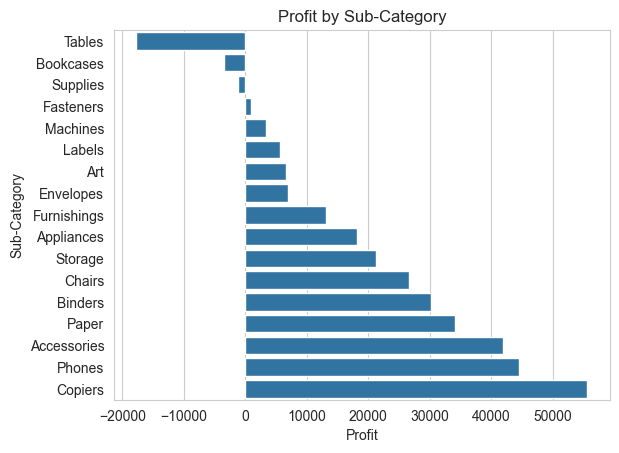

In [13]:
sns.barplot(x=profit_by_subcat.values, y=profit_by_subcat.index)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

### Insight

Some sub-categories generate negative profit.

Tables and Bookcases appear to be loss-making product lines, which helps explain why the Furniture category has relatively low profitability despite strong sales.

## Impact of discounts on profit

We analyze the relationship between discount levels and profit to see if high discounts are driving losses.

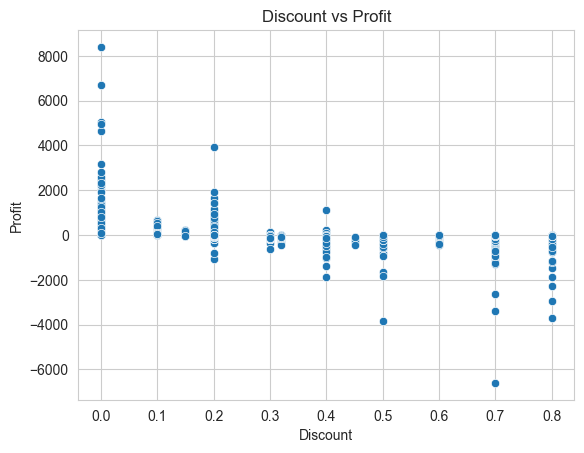

In [14]:
sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Insight

High discount levels are associated with negative profit.

Most transactions with discounts above 40% tend to generate negative profit, suggesting that aggressive discount strategies may harm profitability.

## Sales over time

We analyze how sales evolve over time to identify possible trends or seasonality.

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [16]:
sales_over_time = df.groupby("Order Date")["Sales"].sum()

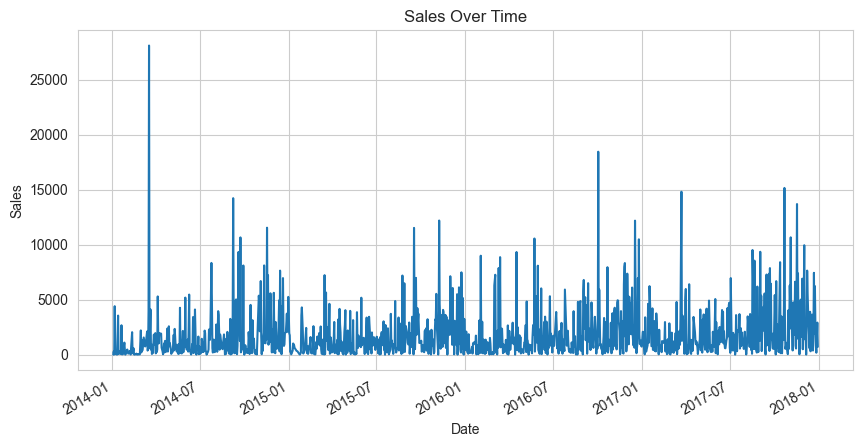

In [17]:
plt.figure(figsize=(10,5))

sales_over_time.plot()

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Insight

Sales fluctuate significantly over time with occasional large spikes.  
The time series suggests variability in daily sales, with some high-volume transactions driving peaks.

## Monthly sales trend

We aggregate sales by month to better observe long-term trends in the business.

In [18]:
monthly_sales = df.resample("ME", on="Order Date")["Sales"].sum()

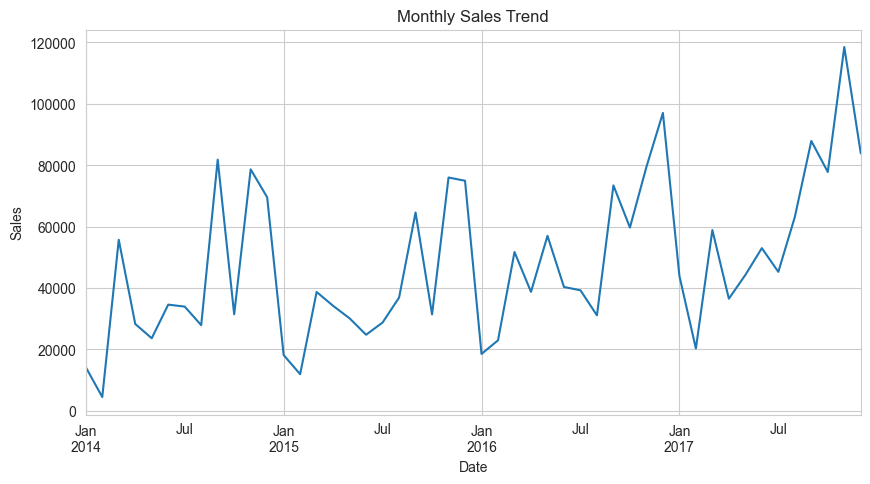

In [19]:
plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Insight

Monthly sales show a clear upward trend from 2014 to 2018, suggesting business growth over time.

Sales also appear to spike toward the end of the year, which may indicate seasonal effects related to holiday shopping.